# pmcx 仿真：250 × 250 × 50 mm 泡沫板 + 32 × 32 探测器阵列

这个 notebook 用于构建一个基于 `pmcx` 的 slab 仿真：

- 泡沫板尺寸：250 × 250 × 50 mm
- 厚度方向：x 轴，0 → 50 mm
- 激光从左侧 `x = 0` 输入，方向为 `+x`
- 探测器阵列放在右侧 `x = 50 mm`
- 探测器阵列：32 × 32
- 视场范围：140 × 140 mm
- 探测器中心间距：140 / 32 = 4.375 mm
- 单探测器有效直径：默认 0.61 mm
- 时间分辨率：55 ps
- 总时间窗：12.5 ns

建议先只运行到几何检查部分，确认源、体素尺寸、探测器位置无误后，再运行 pmcx 仿真。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import pmcx
    print("pmcx imported successfully.")
except ImportError as e:
    print("pmcx is not installed or not available in this environment.")
    print("Install example: pip install pmcx")
    raise e

pmcx imported successfully.


## 1. 全局参数设置

如果后面考虑衍射/像差后的等效探测区域，可以直接修改：

```python
DETECTOR_DIAMETER_MM = 0.70
```

如果 `mus = 1.4` 实际上是约化散射系数 $\mu_s'$，需要用：

```python
MUS_MM_INV = MUS_PRIME_MM_INV / (1 - G)
```

In [2]:
# -----------------------------
# Geometry parameters
# -----------------------------
SLAB_THICKNESS_MM = 50.0
SLAB_WIDTH_MM = 250.0
SLAB_HEIGHT_MM = 250.0

# x axis is the slab thickness direction.
# Simulation volume shape is therefore:
# x: 50 mm, y: 250 mm, z: 250 mm
VOXEL_SIZE_MM = 1.0

# -----------------------------
# Detector array parameters
# -----------------------------
NUM_PIX = 32
FOV_MM = 140.0
DETECTOR_DIAMETER_MM = 0.61  # effective diameter on the field plane

# -----------------------------
# Optical parameters
# -----------------------------
MUA_MM_INV = 0.0019
MUS_MM_INV = 1.4
G = 0
REFRACTIVE_INDEX = 1.4

# If MUS_MM_INV above is actually reduced scattering coefficient mus', uncomment this:
# MUS_PRIME_MM_INV = 1.4
# MUS_MM_INV = MUS_PRIME_MM_INV / (1 - G)

# -----------------------------
# Time parameters
# -----------------------------
TSTEP_PS = 55.0
TOTAL_TIME_NS = 12.5

# -----------------------------
# MC simulation parameters
# -----------------------------
NPHOTON_DEBUG = 1_000_000
NPHOTON_FORMAL = 10_000_000
GPUID = 1
SEED = 123456789

print(f"Detector pitch = {FOV_MM / NUM_PIX:.6f} mm")
print(f"Detector effective diameter = {DETECTOR_DIAMETER_MM:.6f} mm")
print(f"Number of time bins ≈ {np.ceil((TOTAL_TIME_NS * 1e-9) / (TSTEP_PS * 1e-12)).astype(int)}")

Detector pitch = 4.375000 mm
Detector effective diameter = 0.610000 mm
Number of time bins ≈ 228


## 2. 构建 32 × 32 探测器阵列

`detpos` 的每一行是：

$$
[x, y, z, r]
$$

其中坐标和半径都是 **voxel units**，不是 mm。

In [3]:
def build_detector_array_32x32(
    slab_thickness_mm=50.0,
    slab_width_mm=250.0,
    slab_height_mm=250.0,
    fov_mm=140.0,
    num_pix=32,
    detector_diameter_mm=0.61,
    voxel_size_mm=1.0,
    put_on_boundary=True,
):
    """
    Build 32 x 32 detector positions for MCX/pmcx.

    MCX positions are in voxel units, not directly in mm.
    Therefore all physical coordinates are divided by voxel_size_mm.

    Returns
    -------
    detpos : ndarray, shape (1024, 4)
        Each row is [x, y, z, radius] in voxel units.
    yy_mm : ndarray, shape (32,)
        Detector center y positions in mm.
    zz_mm : ndarray, shape (32,)
        Detector center z positions in mm.
    """

    pitch_mm = fov_mm / num_pix

    # Detector centers cover the central 140 x 140 mm area.
    offsets_mm = (np.arange(num_pix) + 0.5) * pitch_mm - fov_mm / 2

    y_center_mm = slab_width_mm / 2
    z_center_mm = slab_height_mm / 2

    yy_mm = y_center_mm + offsets_mm
    zz_mm = z_center_mm + offsets_mm

    if put_on_boundary:
        x_det_mm = slab_thickness_mm
    else:
        x_det_mm = slab_thickness_mm - voxel_size_mm

    det_radius_mm = detector_diameter_mm / 2

    detpos = []
    for z_mm in zz_mm:
        for y_mm in yy_mm:
            detpos.append([
                x_det_mm / voxel_size_mm,
                y_mm / voxel_size_mm,
                z_mm / voxel_size_mm,
                det_radius_mm / voxel_size_mm,
            ])

    return np.asarray(detpos, dtype=np.float32), yy_mm, zz_mm

## 3. 构建 pmcx 配置

In [4]:
def make_foam_slab_cfg(
    nphoton=10_000_000,
    voxel_size_mm=1.0,
    slab_thickness_mm=50.0,
    slab_width_mm=250.0,
    slab_height_mm=250.0,
    mua=0.0019,
    mus=1.4,
    g=0.9,
    n=1.4,
    fov_mm=140.0,
    num_pix=32,
    detector_diameter_mm=0.61,
    tstep_ps=55.0,
    total_time_ns=12.5,
    gpuid=1,
    seed=123456789,
):
    """
    Construct pmcx configuration dictionary.

    Optical property convention for MCX:
        prop row = [mua, mus, g, n]

    Important:
        If 1.4 is actually reduced scattering coefficient mus', use:
            mus = mus_prime / (1 - g)
    """

    nx = int(round(slab_thickness_mm / voxel_size_mm))
    ny = int(round(slab_width_mm / voxel_size_mm))
    nz = int(round(slab_height_mm / voxel_size_mm))

    vol = np.ones((nx, ny, nz), dtype=np.uint8)

    srcpos = [
        0.0,
        (slab_width_mm / 2) / voxel_size_mm,
        (slab_height_mm / 2) / voxel_size_mm,
    ]
    srcdir = [1.0, 0.0, 0.0]

    detpos, yy_mm, zz_mm = build_detector_array_32x32(
        slab_thickness_mm=slab_thickness_mm,
        slab_width_mm=slab_width_mm,
        slab_height_mm=slab_height_mm,
        fov_mm=fov_mm,
        num_pix=num_pix,
        detector_diameter_mm=detector_diameter_mm,
        voxel_size_mm=voxel_size_mm,
        put_on_boundary=True,
    )

    tstart = 0.0
    tend = total_time_ns * 1e-9
    tstep = tstep_ps * 1e-12

    cfg = {
        "nphoton": int(nphoton),
        "vol": vol,
        "unitinmm": voxel_size_mm,
        "prop": [
            [0.0, 0.0, 1.0, 1.0],
            [mua, mus, g, n],
        ],
        "srcpos": srcpos,
        "srcdir": srcdir,
        "srctype": "pencil",
        "detpos": detpos,
        "tstart": tstart,
        "tend": tend,
        "tstep": tstep,
        "seed": seed,
        "gpuid": gpuid,
        "autopilot": 1,
        "issavedet": 1,
        "savedetflag": "dp",
        "outputtype": "flux",
        "debuglevel": "P",
    }

    meta = {
        "voxel_size_mm": voxel_size_mm,
        "volume_shape_voxels": (nx, ny, nz),
        "slab_size_mm": (slab_thickness_mm, slab_width_mm, slab_height_mm),
        "srcpos_vox": srcpos,
        "srcpos_mm": [0.0, slab_width_mm / 2, slab_height_mm / 2],
        "srcdir": srcdir,
        "detpos_vox": detpos,
        "detector_y_mm": yy_mm,
        "detector_z_mm": zz_mm,
        "detector_pitch_mm": fov_mm / num_pix,
        "detector_diameter_mm": detector_diameter_mm,
        "fov_mm": fov_mm,
        "num_pix": num_pix,
        "tstart_s": tstart,
        "tend_s": tend,
        "tstep_s": tstep,
        "num_time_bins_approx": int(np.ceil((tend - tstart) / tstep)),
        "mua_mm_inv": mua,
        "mus_mm_inv": mus,
        "g": g,
        "n": n,
    }

    return cfg, meta

## 4. 几何检查：探测器阵列是否正确放置

先检查探测器是否覆盖了中心的 140 × 140 mm 视场。

In [5]:
cfg_test, meta_test = make_foam_slab_cfg(
    nphoton=NPHOTON_DEBUG,
    voxel_size_mm=VOXEL_SIZE_MM,
    slab_thickness_mm=SLAB_THICKNESS_MM,
    slab_width_mm=SLAB_WIDTH_MM,
    slab_height_mm=SLAB_HEIGHT_MM,
    mua=MUA_MM_INV,
    mus=MUS_MM_INV,
    g=G,
    n=REFRACTIVE_INDEX,
    fov_mm=FOV_MM,
    num_pix=NUM_PIX,
    detector_diameter_mm=DETECTOR_DIAMETER_MM,
    tstep_ps=TSTEP_PS,
    total_time_ns=TOTAL_TIME_NS,
    gpuid=GPUID,
    seed=SEED,
)

print("==== Geometry summary ====")
print(f"Volume shape in voxels: {meta_test['volume_shape_voxels']}")
print(f"Slab size in mm: {meta_test['slab_size_mm']}")
print(f"Source position in mm: {meta_test['srcpos_mm']}")
print(f"Source direction: {meta_test['srcdir']}")
print(f"Detector pitch: {meta_test['detector_pitch_mm']} mm")
print(f"Detector diameter: {meta_test['detector_diameter_mm']} mm")
print(f"Detector y range: {meta_test['detector_y_mm'][0]:.3f} to {meta_test['detector_y_mm'][-1]:.3f} mm")
print(f"Detector z range: {meta_test['detector_z_mm'][0]:.3f} to {meta_test['detector_z_mm'][-1]:.3f} mm")
print(f"Number of detectors: {cfg_test['detpos'].shape[0]}")
print(f"Time step: {meta_test['tstep_s'] * 1e12:.2f} ps")
print(f"Total time window: {meta_test['tend_s'] * 1e9:.2f} ns")
print(f"Approx. number of time bins: {meta_test['num_time_bins_approx']}")

==== Geometry summary ====
Volume shape in voxels: (50, 250, 250)
Slab size in mm: (50.0, 250.0, 250.0)
Source position in mm: [0.0, 125.0, 125.0]
Source direction: [1.0, 0.0, 0.0]
Detector pitch: 4.375 mm
Detector diameter: 0.61 mm
Detector y range: 57.188 to 192.812 mm
Detector z range: 57.188 to 192.812 mm
Number of detectors: 1024
Time step: 55.00 ps
Total time window: 12.50 ns
Approx. number of time bins: 228


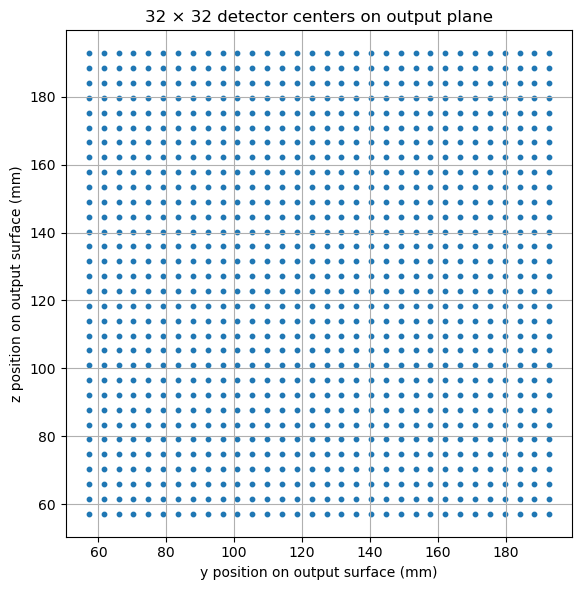

In [6]:
yy, zz = np.meshgrid(meta_test["detector_y_mm"], meta_test["detector_z_mm"])

plt.figure(figsize=(6, 6))
plt.scatter(yy.ravel(), zz.ravel(), s=10)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("y position on output surface (mm)")
plt.ylabel("z position on output surface (mm)")
plt.title("32 × 32 detector centers on output plane")
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. 运行 pmcx 仿真

建议先用 `NPHOTON_DEBUG = 1_000_000` 测试。确认有出射探测光子后，再增大到 `10_000_000` 或更高。

如果只是检查探测器计数，`outputtype="flux"` 可能占用较多显存。显存不够时，可以先去掉 `outputtype`，只保存探测光子。

In [7]:
def run_foam_slab_simulation(
    nphoton=1e6,
    voxel_size_mm=1.0,
    detector_diameter_mm=0.61,
    mua=0.00019,
    mus=1.4,
    g=0,
    n=1.4,
    gpuid=1,
):
    """Run pmcx simulation and return raw result, config, and metadata."""

    cfg, meta = make_foam_slab_cfg(
        nphoton=nphoton,
        voxel_size_mm=voxel_size_mm,
        detector_diameter_mm=detector_diameter_mm,
        mua=mua,
        mus=mus,
        g=g,
        n=n,
        gpuid=gpuid,
    )

    print("==== Simulation summary ====")
    print(f"Volume shape in voxels: {meta['volume_shape_voxels']}")
    print(f"Voxel size: {meta['voxel_size_mm']} mm")
    print(f"Physical slab size: {meta['slab_size_mm']} mm")
    print(f"Detector pitch: {meta['detector_pitch_mm']} mm")
    print(f"Detector effective diameter: {meta['detector_diameter_mm']} mm")
    print(f"Number of detectors: {cfg['detpos'].shape[0]}")
    print(f"Time step: {meta['tstep_s'] * 1e12:.2f} ps")
    print(f"Total time window: {meta['tend_s'] * 1e9:.2f} ns")
    print(f"Approx. number of time bins: {meta['num_time_bins_approx']}")
    print(f"Optical properties: mua={mua}, mus={mus}, g={g}, n={n}")
    print("============================")

    res = pmcx.mcxlab(cfg)
    return res, cfg, meta

In [8]:
# Run this cell to start a debug simulation.
# You can change nphoton=NPHOTON_FORMAL for a larger formal run.

res, cfg, meta = run_foam_slab_simulation(
    nphoton=NPHOTON_DEBUG,
    voxel_size_mm=VOXEL_SIZE_MM,
    detector_diameter_mm=DETECTOR_DIAMETER_MM,
    mua=MUA_MM_INV,
    mus=MUS_MM_INV,
    g=G,
    n=REFRACTIVE_INDEX,
    gpuid=GPUID,
)

==== Simulation summary ====
Volume shape in voxels: (50, 250, 250)
Voxel size: 1.0 mm
Physical slab size: (50.0, 250.0, 250.0) mm
Detector pitch: 4.375 mm
Detector effective diameter: 0.61 mm
Number of detectors: 1024
Time step: 55.00 ps
Total time window: 12.50 ns
Approx. number of time bins: 228
Optical properties: mua=0.0019, mus=1.4, g=0, n=1.4
nphoton: 1e+06
tstart: 0
tstep: 5.5e-11
tend: 1.25e-08
autopilot: 1
unitinmm: 1
issavedet: 1


## 6. 提取探测器计数并画 32 × 32 图

不同版本的 `pmcx` 返回的 detected photon 数据结构可能略有差异。  
如果没有自动找到 detector ID，先看打印出来的 `res.keys()`。

In [9]:
def extract_detector_id_from_detp(detp):
    """Try to extract detector ID from pmcx detected photon output."""

    if detp is None:
        return None

    if isinstance(detp, dict):
        for key in ["detid", "det", "detid_data", "d"]:
            if key in detp:
                return np.asarray(detp[key]).astype(int)

    if isinstance(detp, np.ndarray):
        if detp.ndim == 2 and detp.shape[1] >= 1:
            return detp[:, 0].astype(int)

    return None


def quick_plot_detector_counts(res, num_pix=32):
    """Plot the number of detected photons per detector as a 32 x 32 image."""

    print("Result type:", type(res))
    if isinstance(res, dict):
        print("Result keys:", list(res.keys()))

    detp = None
    if isinstance(res, dict):
        for key in ["detp", "detphoton", "detphotons"]:
            if key in res:
                detp = res[key]
                break

    detid = extract_detector_id_from_detp(detp)

    if detid is None:
        print("Could not find detector IDs in result.")
        print("Check the pmcx result structure above.")
        return None

    detid = detid.astype(int)
    if detid.min() == 1:
        detid0 = detid - 1
    else:
        detid0 = detid

    counts = np.bincount(detid0, minlength=num_pix * num_pix)
    img = counts.reshape(num_pix, num_pix)

    plt.figure(figsize=(6, 5))
    plt.imshow(img, origin="lower")
    plt.colorbar(label="Detected photon counts")
    plt.title("32 × 32 detector counts")
    plt.xlabel("Detector y index")
    plt.ylabel("Detector z index")
    plt.tight_layout()
    plt.show()

    return img

In [10]:
det_img = quick_plot_detector_counts(res, num_pix=NUM_PIX)

Result type: <class 'dict'>
Result keys: ['flux', 'stat']
Could not find detector IDs in result.
Check the pmcx result structure above.


In [14]:
res["flux"].shape

(50, 250, 250, 227)

## 7. 保存元数据和探测器计数

这一步不是必须的。  
`.npz` 适合保存多个 NumPy 数组和参数；`.npy` 适合保存单个数组。

In [ ]:
np.savez(
    "foam_slab_32x32_pmcx_result_meta.npz",
    detpos_vox=meta["detpos_vox"],
    detector_y_mm=meta["detector_y_mm"],
    detector_z_mm=meta["detector_z_mm"],
    detector_pitch_mm=meta["detector_pitch_mm"],
    detector_diameter_mm=meta["detector_diameter_mm"],
    voxel_size_mm=meta["voxel_size_mm"],
    slab_size_mm=np.asarray(meta["slab_size_mm"]),
    tstart_s=meta["tstart_s"],
    tend_s=meta["tend_s"],
    tstep_s=meta["tstep_s"],
    mua_mm_inv=meta["mua_mm_inv"],
    mus_mm_inv=meta["mus_mm_inv"],
    g=meta["g"],
    n=meta["n"],
)

if det_img is not None:
    np.save("foam_slab_32x32_detector_counts.npy", det_img)
    print("Saved detector count image to foam_slab_32x32_detector_counts.npy")

print("Saved metadata to foam_slab_32x32_pmcx_result_meta.npz")

## 8. 可选：读取保存后的结果

In [ ]:
data = np.load("foam_slab_32x32_pmcx_result_meta.npz")
print(data.files)

try:
    loaded_det_img = np.load("foam_slab_32x32_detector_counts.npy")
    plt.figure(figsize=(6, 5))
    plt.imshow(loaded_det_img, origin="lower")
    plt.colorbar(label="Detected photon counts")
    plt.title("Loaded 32 × 32 detector counts")
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print("Detector count file not found. Run the simulation and saving cells first.")